In [1]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 기본 스타일 베이스 설정
plt.style.use("seaborn-v0_8-whitegrid")

# 2. 글로벌 디자인 세팅 (rcParams)
plt.rcParams.update({
    "figure.figsize": (6, 4),       # 기본 그래프 크기
    "figure.facecolor": "white",      # 배경색 흰색
    "axes.facecolor": "white",        # 축 안쪽 배경색
    "axes.grid": True,                # 그리드 표시 여부
    "grid.color": "#EAEAEA",          # 그리드 선 색상 (연한 회색)
    "axes.axisbelow": True,           # 그리드 선을 데이터 뒤로 배치

    # 폰트 및 색상 설정
    "text.color": "#333333",          # 기본 텍스트 색상
    "axes.labelcolor": "#333333",     # 축 레이블 색상
    "xtick.color": "#555555",         # x축 눈금 색상
    "ytick.color": "#555555",         # y축 눈금 색상
    "axes.labelsize": 11,             # 축 레이블 폰트 크기
    "axes.titlesize": 14,             # 타이틀 폰트 크기
    "axes.titleweight": "bold",       # 타이틀 폰트 굵기
    "xtick.labelsize": 10,            # x축 눈금 폰트 크기
    "ytick.labelsize": 10,            # y축 눈금 폰트 크기

    # 범례(Legend) 디자인
    "legend.frameon": True,           # 범례 테두리 켜기
    "legend.facecolor": "white",      # 범례 배경색
    "legend.edgecolor": "none",       # 범례 테두리 없애기
    "legend.fontsize": 10             # 범례 폰트 크기
})

In [2]:
from pathlib import Path
import pandas as pd

# ------------------------------------------------------------------------------
# Configs
# ------------------------------------------------------------------------------
ROOT = Path("/content/drive/MyDrive/DAHS/datasets/3.1_subset")

HOSP_DIR = ROOT / "hosp"
ICU_DIR = ROOT / "icu"

# ------------------------------------------------------------------------------
# Load csvs
# ------------------------------------------------------------------------------

# hosp
patients_path = HOSP_DIR / "patients.csv.gz"
patients = pd.read_csv(patients_path)

admissions_path = HOSP_DIR / "admissions.csv.gz"
admissions = pd.read_csv(admissions_path)

labevents_path = HOSP_DIR / "labevents.csv.gz"
labevents = pd.read_csv(labevents_path)

d_labitems_path = HOSP_DIR / "d_labitems.csv.gz"
d_labitems = pd.read_csv(d_labitems_path)

# icu
chartevents_path = ICU_DIR / "chartevents.csv.gz"
chartevents = pd.read_csv(chartevents_path)

inputevents_path = ICU_DIR / "inputevents.csv.gz"
inputevents = pd.read_csv(inputevents_path)

d_items_path = ICU_DIR / "d_items.csv.gz"
d_items = pd.read_csv(d_items_path)

icustays_path = ICU_DIR / "icustays.csv.gz"
icustays = pd.read_csv(icustays_path)

/tmp/ipykernel_1221/2705080484.py:24: DtypeWarning: Columns (5) have mixed types. Specify dtype option on import or set low_memory=False.
  labevents = pd.read_csv(labevents_path)


In [3]:
procedureevents_path = ICU_DIR / "procedureevents.csv.gz"
procedureevents = pd.read_csv(procedureevents_path)

In [4]:
# ------------------------------------------------------------------------------
# 분석 기간 / 수집 시점
# ------------------------------------------------------------------------------
print(patients["anchor_year_group"].value_counts(dropna=False).sort_index())
print()
print(patients["anchor_year"].describe())
print()

tmp = icustays.copy()
tmp["intime"] = pd.to_datetime(tmp["intime"], errors="coerce")
print("min shifted t: ", tmp["intime"].min())
print("max shifted t: ", tmp["intime"].max())

print("anchor_year missing: ", patients["anchor_year"].isna().sum())
print("anchor_year_group missing: ", patients["anchor_year_group"].isna().sum())

anchor_year_group
2008 - 2010    810
2011 - 2013    558
2014 - 2016    538
2017 - 2019    454
2020 - 2022    430
Name: count, dtype: int64

count    2790.000000
mean     2151.092473
std        23.655379
min      2110.000000
25%      2131.000000
50%      2151.000000
75%      2172.000000
max      2204.000000
Name: anchor_year, dtype: float64

min shifted t:  2110-02-12 16:39:55
max shifted t:  2213-10-02 07:37:35
anchor_year missing:  0
anchor_year_group missing:  0


Age Range:  count    2790.000000
mean       61.928315
std        15.512145
min        18.000000
25%        52.000000
50%        63.000000
75%        74.000000
max        91.000000
Name: anchor_age, dtype: float64

Age < 16:  0
Age < 100:  0
missing?:  0


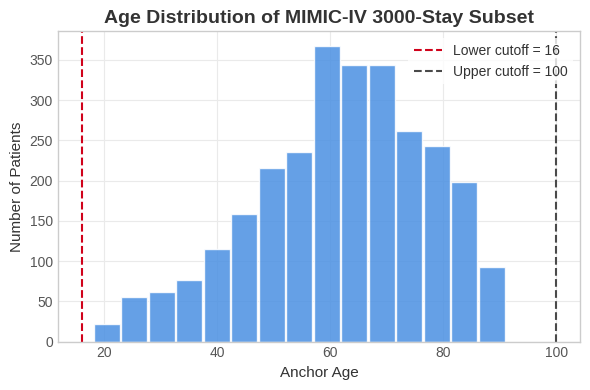

In [5]:
# ------------------------------------------------------------------------------
# Age
# ------------------------------------------------------------------------------
print("Age Range: ", patients["anchor_age"].describe())
print()
print("Age < 16: ", (patients["anchor_age"] < 16).sum())
print("Age < 100: ", (patients["anchor_age"] > 100).sum())
print("missing?: ", patients["anchor_age"].isna().sum())

# figure
ages = patients["anchor_age"].dropna()
plt.hist(ages, bins=15, color="#4A90E2", edgecolor="white", alpha=0.85, rwidth=0.95)
plt.axvline(16, color="#D0021B", linestyle="--", linewidth=1.5, label="Lower cutoff = 16")
plt.axvline(100, color="#4A4A4A", linestyle="--", linewidth=1.5, label="Upper cutoff = 100")
plt.xlabel("Anchor Age")
plt.ylabel("Number of Patients")
plt.title("Age Distribution of MIMIC-IV 3000-Stay Subset")
plt.legend()
plt.tight_layout()
plt.show()

In [6]:
# ------------------------------------------------------------------------------
# Full Machanical Circulatory Support
# MIMIC IV의 어디에 실제로 exclusion할 정보들이 있을지 탐색
# HiRID의 ECMO/assist + MIMIC III의 ECMO/LVAD/RVAD/Impella/IABP
# ------------------------------------------------------------------------------
import re

keywords = [
    "ECMO",
    "assist device",
    "ventricular assist",
    "LVAD",
    "RVAD",
    "Impella",
    "IABP",
    "intra-aortic",
    "balloon pump",
]

pattern = "|".join(re.escape(k) for k in keywords)
mcs_candidates = d_items[d_items["label"].fillna("").str.contains(pattern, case=False, regex=True)].copy()

cols = [c for c in ["itemid", "label", "linksto", "category", "unitname", "param_type"]
        if c in mcs_candidates.columns]


print("Candidate ITEMIDs:", len(mcs_candidates))

display(mcs_candidates[cols].sort_values(["linksto", "label", "itemid"]).reset_index(drop=True))

Candidate ITEMIDs: 99


,itemid,label,linksto,category,unitname,param_type
0,224318,ABI Ankle BP L (Impella),chartevents,Impella,mmHg,Numeric
1,228148,ABI Ankle BP R (Impella),chartevents,Impella,mmHg,Numeric
2,228149,ABI Brachial BP L (Impella),chartevents,Impella,mmHg,Numeric
3,224314,ABI Brachial BP R (Impella),chartevents,Impella,mmHg,Numeric
4,228867,Assist Device,chartevents,Treatments,NaN,Text
...,...,...,...,...,...,...
94,229597,Heparin Sodium (Impella),inputevents,Medications,units,Solution
95,229529,ECMO Inflow Line,procedureevents,Access Lines - Invasive,NaN,Processes
96,229530,ECMO Outflow Line,procedureevents,Access Lines - Invasive,NaN,Processes
97,224272,IABP line,procedureevents,Access Lines - Invasive,NaN,Processes


In [7]:
# 생각보다 너무 많아서 그냥 디바이스별로 "어디에 어떤 정보가 있는지" 출력
summary = (
    mcs_candidates[
        ["label", "category", "linksto"]
    ]
    .drop_duplicates()
    .sort_values(["label", "category", "linksto"])
)

for _, row in summary.iterrows():
    print(
        f"{row['label']} ({row['category']}) -> {row['linksto']}"
    )

ABI Ankle BP L (Impella) (Impella) -> chartevents
ABI Ankle BP R (Impella) (Impella) -> chartevents
ABI Brachial BP L (Impella) (Impella) -> chartevents
ABI Brachial BP R (Impella) (Impella) -> chartevents
Assist Device (Treatments) -> chartevents
Bivalirudin (Angiomax) (Impella) (Medications) -> inputevents
Cannula sites visually inspected (ECMO) (ECMO) -> chartevents
Cannula sites visually inspected (LVAD) (Centrimag) -> chartevents
Cannula sites visually inspected (RVAD) (Centrimag) -> chartevents
Cardiac Output (CO) (Impella) (Impella) -> chartevents
Circuit Configuration (ECMO) (ECMO) -> chartevents
Circuit inspected for clot (ECMO) (ECMO) -> chartevents
Delta P (ECMO) (ECMO) -> chartevents
Delta P Alarm (ECMO) (ECMO) -> chartevents
ECMO (Hemodynamics) -> chartevents
ECMO Inflow Line (Access Lines - Invasive) -> procedureevents
ECMO Outflow Line (Access Lines - Invasive) -> procedureevents
Emergency Equipment at bedside (ECMO) (ECMO) -> chartevents
Emergency Equipment at bedside (

### 논문의 HiRID 순환계 보조관련인 ECMO
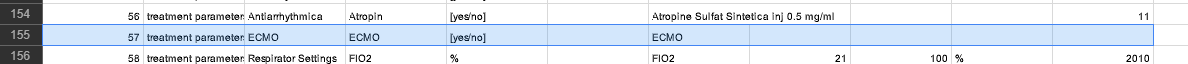

### 논문의 MIMIC III exclusion 목록
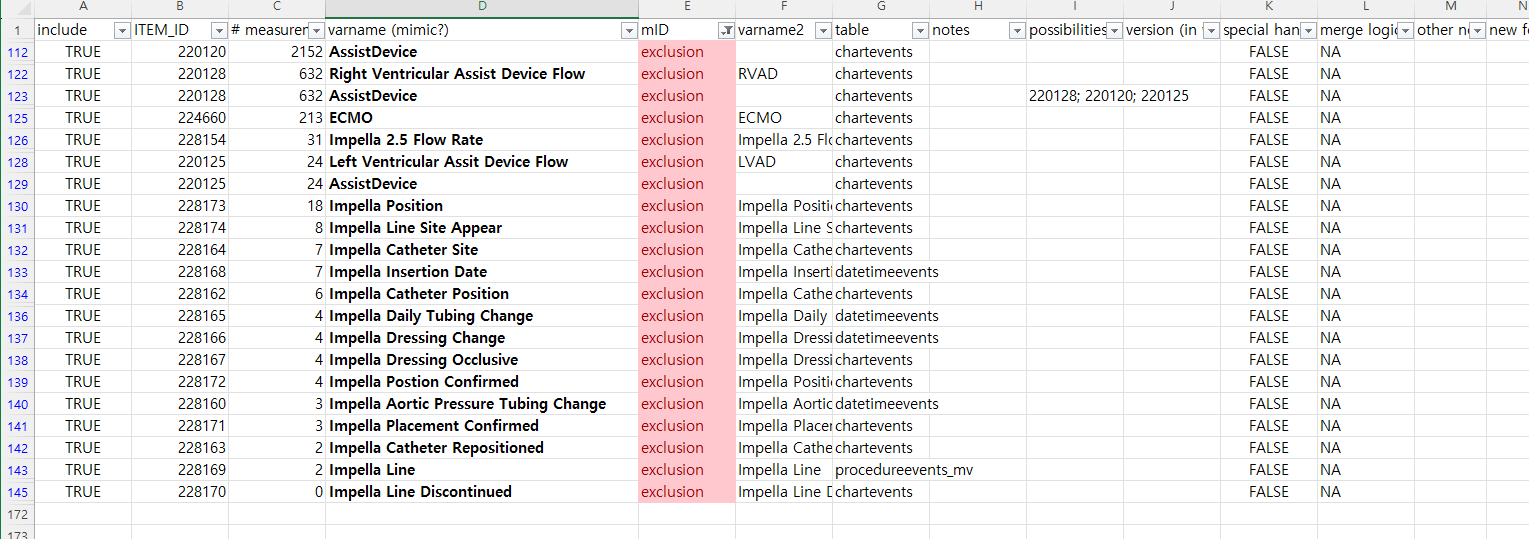

In [8]:
# 저자와 동일하게 `mimic_vars.csv`처럼 `mimic_mcs_exclusion.csv`를 생성 후,
# 나중에 preprocessing 단계에서 활용
#
# MIMIC-IV 재현 시...
# HiRID, MIMIC III의 exlcution 항목과 직접 대응하면 exclusion,
# MIMIC-IV에서 새롭게 나온 항목은 판단 제외


# HiRID
hirid = pd.read_csv("/content/drive/MyDrive/DAHS/datasets/varref_excel_v6.tsv",
                    sep="\t", encoding="latin1")

hirid_names = set(hirid.loc[hirid["MetaVariableName"].eq("ECMO"),
                            "MetaVariableName"].dropna())


# MIMIC III
mimic3 = pd.read_csv("/content/drive/MyDrive/DAHS/datasets/mimic_vars.csv")

mimic3_names = set(mimic3.loc[mimic3["mID"].eq("exclusion"),
                              "varname (mimic?)"].dropna())


# 둘 ITEM 이름들 합침
reference_names = hirid_names | mimic3_names


# MIMIC IV cadidates
mapping = mcs_candidates[["itemid", "label", "category", "linksto"]].copy()

mapping["status"] = mapping["label"].apply(
    lambda x: "exclude" if x in reference_names else "pending"
)


# Save csv
mapping.to_csv("/content/drive/MyDrive/DAHS/datasets/mimic4_mcs_exclusion.csv",
               index=False)

print("Reference names: ", len(reference_names))
print(mapping["status"].value_counts())

display(mapping)

Reference names:  19
status
pending    83
exclude    16
Name: count, dtype: int64


,itemid,label,category,linksto,status
23,220128,Right Ventricular Assist Device Flow,Hemodynamics,chartevents,exclude
603,224272,IABP line,Access Lines - Invasive,procedureevents,pending
631,224314,ABI Brachial BP R (Impella),Impella,chartevents,pending
634,224318,ABI Ankle BP L (Impella),Impella,chartevents,pending
635,224322,IABP Mean,IABP,chartevents,pending
...,...,...,...,...,...
4082,230164,StO2 L (ECMO),ECMO,chartevents,pending
4086,230168,Delta P (ECMO),ECMO,chartevents,pending
4087,230169,Delta P Alarm (ECMO),ECMO,chartevents,pending
4088,230170,Part Alarm (Hi) (ECMO),ECMO,chartevents,pending


In [9]:
# ------------------------------------------------------------------------------
# 실제 측정 시간, 시스템 입력 시간 및 Time variable 처리
# HiRID - 엑셀 참고 (수동-> 자동 동기화)
# MIMIC III - CHARTTIME, STARTTIME, ENDTIME 등을 읽어서 HiRID 형식의 Datetime으로 변환함
# ------------------------------------------------------------------------------

# Shifted된 시간을 Datetime 변환만 수행하고 그대로 사용할 것이기에 변환 확인만
time_checks = {
    "icustays": ["intime", "outtime"],
    "chartevents": ["charttime", "storetime"],
    "labevents": ["charttime", "storetime"],
    "inputevents": ["starttime", "endtime", "storetime"],
    "procedureevents": ["starttime", "endtime", "storetime"],
}

tables = {
    "icustays": icustays,
    "chartevents": chartevents,
    "labevents": labevents,
    "inputevents": inputevents,
    "procedureevents": procedureevents,
}

for table_name, cols in time_checks.items():
    df = tables[table_name]

    print(f"\n=== {table_name} ===")

    for col in cols:
        if col not in df.columns:
            print(f"{col}: column not found")
            continue

        converted = pd.to_datetime(df[col], errors="coerce")

        print(
            f"{col}: "
            f"NaT={converted.isna().sum():,} / {len(converted):,} "
            f"({converted.isna().mean()*100:.4f}%)"
        )

        if converted.notna().any():
            print(
                f"    range: "
                f"{converted.min()} ~ {converted.max()}"
            )


=== icustays ===
intime: NaT=0 / 3,000 (0.0000%)
    range: 2110-02-12 16:39:55 ~ 2213-10-02 07:37:35
outtime: NaT=0 / 3,000 (0.0000%)
    range: 2110-02-14 20:43:32 ~ 2213-10-03 17:29:56

=== chartevents ===
charttime: NaT=0 / 31,295,077 (0.0000%)
    range: 2110-02-12 16:00:00 ~ 2213-10-03 17:00:00
storetime: NaT=41,563 / 31,295,077 (0.1328%)
    range: 2110-02-12 17:01:00 ~ 2213-10-03 17:24:00

=== labevents ===
charttime: NaT=0 / 3,508,887 (0.0000%)
    range: 2110-02-10 15:46:00 ~ 2213-10-14 08:35:00
storetime: NaT=12,538 / 3,508,887 (0.3573%)
    range: 2110-02-10 16:01:00 ~ 2213-10-14 09:50:00

=== inputevents ===
starttime: NaT=0 / 813,092 (0.0000%)
    range: 2110-02-12 17:46:00 ~ 2209-05-30 15:47:00
endtime: NaT=0 / 813,092 (0.0000%)
    range: 2110-02-12 20:08:00 ~ 2209-05-30 18:11:00
storetime: NaT=0 / 813,092 (0.0000%)
    range: 2110-02-12 17:48:00 ~ 2209-05-30 15:47:00

=== procedureevents ===
starttime: NaT=0 / 44,809 (0.0000%)
    range: 2110-02-12 16:40:00 ~ 2209-05-

In [10]:
# ------------------------------------------------------------------------------
# Blood gas 측정 방식&산소포화도, Central Venous 산소포화도
# HiRID - 엑셀 참고
# MIMIC III - 50813을 aLac(aterial Lactate variable)로 매핑해서 사용
# ------------------------------------------------------------------------------

# 후보 Lactate ITEMID의 dictionary 정보 확인
lactate_items = d_labitems[
    d_labitems["label"].fillna("").str.contains("lactate", case=False, regex=False)
].copy()

display(
    lactate_items[["itemid", "label", "fluid", "category"]].sort_values("itemid")
)

,itemid,label,fluid,category
11,50813,Lactate,Blood,Blood Gas
41,50843,"Lactate Dehydrogenase, Ascites",Ascites,Chemistry
151,50954,Lactate Dehydrogenase (LD),Blood,Chemistry
242,51054,"Lactate Dehydrogenase, Pleural",Pleural,Chemistry
911,51795,"Lactate Dehydrogenase, CSF",Cerebrospinal Fluid,Chemistry
1035,51944,"Lactate Dehydrogenase, Stool",Stool,Chemistry
1516,52442,Lactate,Blood,Blood Gas
1615,53154,Lactate,Blood,Chemistry


In [11]:
# 후보인 50813, 52442, 53154 확인
LACTATE_CANDIDATES = [50813, 52442, 53154]


# 후보들 정보 d_labitems에서 가져오기
lactate_info = d_labitems[d_labitems["itemid"].isin(LACTATE_CANDIDATES)][
    ["itemid", "label", "fluid", "category"]
].copy()


# 실제 측정된 개수(횟수) 확인하기
counts = (labevents[labevents["itemid"].isin(LACTATE_CANDIDATES)]["itemid"]
          .value_counts()
          .reindex(LACTATE_CANDIDATES, fill_value=0)
          .rename("n_measurements")
          .reset_index()
)


# info랑 count 합쳐서 table 만들기
audit = lactate_info.merge(counts, on="itemid", how="left")
audit["n_measurements"] = audit["n_measurements"].fillna(0).astype(int)
display(audit)


unit_counts = (
    labevents[
        labevents["itemid"].isin(LACTATE_CANDIDATES)
    ]
    .groupby(["itemid", "valueuom"])
    .size()
    .reset_index(name="count")
)

display(unit_counts)


# 측정된 개수(횟수)가 하나라도 있는 item들 display
selected = audit[audit["n_measurements"] > 0]

print("\n=== Selected lactate item(s) ===")
display(selected)

,itemid,label,fluid,category,n_measurements
0,50813,Lactate,Blood,Blood Gas,36808
1,52442,Lactate,Blood,Blood Gas,0
2,53154,Lactate,Blood,Chemistry,0


,itemid,valueuom,count
0,50813,mmol/L,36808



=== Selected lactate item(s) ===


,itemid,label,fluid,category,n_measurements
0,50813,Lactate,Blood,Blood Gas,36808


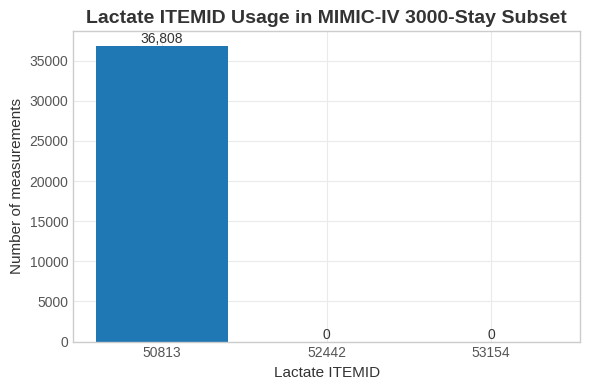

In [12]:
plt.bar(
    audit["itemid"].astype(str),
    audit["n_measurements"]
)

plt.xlabel("Lactate ITEMID")
plt.ylabel("Number of measurements")
plt.title("Lactate ITEMID Usage in MIMIC-IV 3000-Stay Subset")

for i, value in enumerate(audit["n_measurements"]):
    plt.text(
        i,
        value,
        f"{value:,}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

In [13]:
# ------------------------------------------------------------------------------
# Height, Weight
# ------------------------------------------------------------------------------

# height, weight itemid를 d_items에서 찾기
hw_items = d_items[d_items["label"].fillna("").str.contains(
    r"height|weight",
    case=False,
    regex=True
)][["itemid", "label", "category", "linksto"]].sort_values(["label", "itemid"])

display(hw_items)

,itemid,label,category,linksto
1950,226740,APACHE II Diagnosistic weight factors - Medical,Scores - APACHE II,chartevents
1952,226742,APACHE II Diagnosistic weight factors - Surgical,Scores - APACHE II,chartevents
1951,226741,APACHE II Diagnosistic weight factors - Surgic...,Scores - APACHE II,chartevents
1856,226512,Admission Weight (Kg),General,chartevents
1866,226531,Admission Weight (lbs.),General,chartevents
764,224639,Daily Weight,General,chartevents
1993,226846,Feeding Weight,General,chartevents
1941,226707,Height,General,chartevents
1945,226730,Height (cm),General,chartevents
1097,225124,Unintentional weight loss >10 lbs.,Adm History/FHPA,chartevents


In [14]:
# MIMIC III도 확인

mask = mimic3.apply(
    lambda col: col.astype(str).str.contains(
        r"height|weight",
        case=False,
        regex=True,
        na=False
    )
).any(axis=1)

display(mimic3[mask])

,include,ITEM_ID,# measurements (all tables),varname (mimic?),mID,varname2,table,notes,possibilities,version (in which this is a top variable),special handling?,merge logic,other notes,new for MIMIC rerun,# measurements
81,False,224639.0,46452.0,Daily Weight,vm131,Daily Weight,chartevents,NaN,NaN,v6b,FALSE,median,NaN,NaN,NaN
82,True,226531.0,46255.0,Admission Weight (lbs.),vm131,Admission Weight (lbs.),chartevents,NaN,NaN,v6b,TRUE,median,NaN,NaN,NaN
90,True,226512.0,22604.0,Admission Weight (Kg),vm131,Admission Weight (Kg),chartevents,NaN,NaN,v6b,FALSE,median,NaN,NaN,NaN
97,False,226707.0,12015.0,Height,static,Height,chartevents,this is just the inches version of 226730 (unl...,NaN,NaN,TODO,median,NaN,NaN,NaN
98,True,226730.0,12015.0,Height (cm),static,Height (cm),chartevents,NaN,NaN,NaN,FALSE,median,NaN,NaN,NaN


MIMIC III -> Height (cm), Admission Weight(kg), Admission Weight (lbs.) 3개를 사용
+ 중복값들 merge logic은 "median"

In [15]:
# MIMIC III와 동일한 3개 값들의 범위 확인
HEIGHT_CM = 226730
WEIGHT_KG = 226512
WEIGHT_LB = 226531

for itemid, name in [
    (HEIGHT_CM, "Height (cm)"),
    (WEIGHT_KG, "Admission Weight (kg)"),
    (WEIGHT_LB, "Admission Weight (lbs)")
]:
    x = chartevents[
        (chartevents["itemid"] == itemid)
        & chartevents["valuenum"].notna()
    ]["valuenum"]

    print(f"\n=== {name} / ITEMID {itemid} ===")
    print(x.describe())


=== Height (cm) / ITEMID 226730 ===
count    1957.000000
mean      169.063413
std        12.322596
min        13.000000
25%       163.000000
50%       170.000000
75%       178.000000
max       201.000000
Name: valuenum, dtype: float64

=== Admission Weight (kg) / ITEMID 226512 ===
count    2567.000000
mean       83.512193
std        25.407713
min         1.000000
25%        67.000000
50%        79.200000
75%        95.550000
max       275.000000
Name: valuenum, dtype: float64

=== Admission Weight (lbs) / ITEMID 226531 ===
count    6161.000000
mean      183.792787
std        55.823973
min         2.200000
25%       147.800000
50%       174.200000
75%       210.800000
max       605.000000
Name: valuenum, dtype: float64


In [16]:
"""
Table 4 정의
→ 저자 MIMIC-III 실제 mapping
→ MIMIC-IV dictionary에서 동일 ITEMID 존재?
→ label/concept 동일?
→ 어느 table에 있는가?
→ 우리 3,000 stays에 실제 row가 존재?
→ 몇 stay에서 존재?
→ unit은 무엇인가?
→ 최종적으로 Direct / Adapted / Unresolved
"""

# ============================================================
# FULL Table 4 → MIMIC-III → MIMIC-IV Mapping Audit
# ============================================================

import pandas as pd
import numpy as np
import re
from difflib import SequenceMatcher

TABLE4_PATH = "/content/drive/MyDrive/DAHS/datasets/Supplementary_TABLE4.xlsx"
MIMIC3_MAP_PATH = "/content/drive/MyDrive/DAHS/datasets/mimic_vars.csv"


# ============================================================
# 1. Load source files
# ============================================================

table4 = pd.read_excel(
    TABLE4_PATH,
    sheet_name="master list"
)

mimic3 = pd.read_csv(MIMIC3_MAP_PATH)


# ============================================================
# 2. Helper functions
# ============================================================

def parse_itemids(x):
    """Extract integer ITEMIDs from Table 4 cells."""
    if pd.isna(x):
        return []

    text = str(x)

    if "not available" in text.lower():
        return []

    return list(dict.fromkeys(
        int(v) for v in re.findall(r"\d+", text)
    ))


def normalize_text(x):
    """Normalize labels for rough semantic comparison."""
    if pd.isna(x):
        return ""

    x = str(x).lower()
    x = re.sub(r"[^a-z0-9]+", " ", x)
    x = re.sub(r"\s+", " ", x).strip()

    return x


def similarity(a, b):
    a = normalize_text(a)
    b = normalize_text(b)

    if not a or not b:
        return 0

    return SequenceMatcher(None, a, b).ratio()


# ============================================================
# 3. Parse Table 4 MIMIC ITEMIDs
# ============================================================

table4["table4_itemids"] = (
    table4["MIMIC varids"]
    .apply(parse_itemids)
)


# ============================================================
# 4. Prepare MIMIC-III author mapping
# ============================================================

# only variables actually used by the authors
mimic3_used = mimic3[
    mimic3["include"]
    .astype(str)
    .str.lower()
    .eq("true")
].copy()

mimic3_used["ITEM_ID"] = pd.to_numeric(
    mimic3_used["ITEM_ID"],
    errors="coerce"
)

mimic3_used = mimic3_used.dropna(subset=["ITEM_ID"])
mimic3_used["ITEM_ID"] = mimic3_used["ITEM_ID"].astype(int)


# ============================================================
# 5. Build MIMIC-IV dictionary
# ============================================================

icu_dict = d_items[
    ["itemid", "label", "category", "linksto"]
].copy()

icu_dict["fluid"] = np.nan
icu_dict["dictionary"] = "d_items"


lab_dict = d_labitems[
    ["itemid", "label", "category", "fluid"]
].copy()

lab_dict["linksto"] = "labevents"
lab_dict["dictionary"] = "d_labitems"


mimic4_dict = pd.concat(
    [icu_dict, lab_dict],
    ignore_index=True
)

mimic4_dict["itemid"] = pd.to_numeric(
    mimic4_dict["itemid"],
    errors="coerce"
)

mimic4_dict = mimic4_dict.dropna(subset=["itemid"]).copy()
mimic4_dict["itemid"] = mimic4_dict["itemid"].astype(int)

mimic4_ids = set(mimic4_dict["itemid"])


# ============================================================
# 6. Actual subset event tables
# ============================================================

# Only include tables that actually exist in your notebook
event_tables = {}

if "chartevents" in globals():
    event_tables["chartevents"] = chartevents

if "labevents" in globals():
    event_tables["labevents"] = labevents

if "inputevents" in globals():
    event_tables["inputevents"] = inputevents

if "procedureevents" in globals():
    event_tables["procedureevents"] = procedureevents


# ============================================================
# 7. Count actual ITEMID use
# ============================================================

actual_stats = []

for table_name, df in event_tables.items():

    if "itemid" not in df.columns:
        continue

    # Count rows
    counts = (
        df.groupby("itemid")
        .size()
        .rename("n_rows")
        .reset_index()
    )

    # Count stays if available
    if "stay_id" in df.columns:

        stay_counts = (
            df.dropna(subset=["stay_id"])
            .groupby("itemid")["stay_id"]
            .nunique()
            .rename("n_stays")
            .reset_index()
        )

        counts = counts.merge(
            stay_counts,
            on="itemid",
            how="left"
        )

    else:
        counts["n_stays"] = np.nan

    counts["actual_table"] = table_name

    actual_stats.append(counts)


if actual_stats:
    actual_stats = pd.concat(
        actual_stats,
        ignore_index=True
    )
else:
    actual_stats = pd.DataFrame(
        columns=[
            "itemid",
            "n_rows",
            "n_stays",
            "actual_table"
        ]
    )


# ============================================================
# 8. Unit information
# ============================================================

unit_records = []

for table_name, df in event_tables.items():

    if "itemid" not in df.columns:
        continue

    if "valueuom" not in df.columns:
        continue

    tmp = (
        df[
            ["itemid", "valueuom"]
        ]
        .drop_duplicates()
    )

    tmp["actual_table"] = table_name

    unit_records.append(tmp)


if unit_records:

    unit_df = pd.concat(
        unit_records,
        ignore_index=True
    )

    unit_summary = (
        unit_df.groupby("itemid")["valueuom"]
        .apply(
            lambda x: "; ".join(
                sorted(
                    set(
                        str(v)
                        for v in x.dropna()
                    )
                )
            )
        )
        .rename("actual_units")
        .reset_index()
    )

else:

    unit_summary = pd.DataFrame(
        columns=["itemid", "actual_units"]
    )


# ============================================================
# 9. Special MIMIC-IV adaptations already known
# ============================================================

# These are NOT event ITEMID mappings.
# They are source changes required by MIMIC-IV.

SPECIAL_ADAPTATIONS = {

    "static_Age": {
        "source": "patients.anchor_age",
        "reason":
            "MIMIC-IV age is provided through patients.anchor_age; "
            "do not reconstruct age from Date of Birth."
    },

    "static_Height": {
        "source": "chartevents ITEMID 226730",
        "reason":
            "Use Height (cm), consistent with the authors' MIMIC mapping."
    },

    "RelDatetime": {
        "source": "derived from icustays.intime",
        "reason":
            "time since admission is derived, not a raw ITEMID."
    }
}


# ============================================================
# 10. Find author MIMIC-III rows by circEWS ID
# ============================================================

def get_author_rows(var_id):

    return mimic3_used[
        mimic3_used["mID"]
        .astype(str)
        .str.strip()
        .eq(str(var_id).strip())
    ]


# ============================================================
# 11. Get actual MIMIC-IV evidence for ITEMIDs
# ============================================================

def get_actual_evidence(itemids):

    if not itemids:
        return {
            "n_rows": 0,
            "n_stays": 0,
            "actual_tables": "",
            "actual_units": ""
        }

    stats = actual_stats[
        actual_stats["itemid"].isin(itemids)
    ]

    units = unit_summary[
        unit_summary["itemid"].isin(itemids)
    ]

    n_rows = int(stats["n_rows"].sum()) if len(stats) else 0

    # Do NOT sum n_stays across ITEMIDs as unique stay IDs
    # may overlap. This is only an informative maximum-like field.
    n_stays = (
        int(stats["n_stays"].max())
        if len(stats) and stats["n_stays"].notna().any()
        else 0
    )

    actual_tables_str = "; ".join(
        sorted(stats["actual_table"].dropna().unique())
    )

    unit_str = "; ".join(
        sorted(
            set(
                u
                for u in units["actual_units"]
                if isinstance(u, str) and u
            )
        )
    )

    return {
        "n_rows": n_rows,
        "n_stays": n_stays,
        "actual_tables": actual_tables_str,
        "actual_units": unit_str
    }


# ============================================================
# 12. Audit each Table-4 variable
# ============================================================

def audit_variable(row):

    var_id = row["ID"]
    var_name = row["variable name (English)"]

    # --------------------------------------------------------
    # Table-4 mapping
    # --------------------------------------------------------

    table4_ids = row["table4_itemids"]

    # --------------------------------------------------------
    # Author MIMIC-III mapping
    # --------------------------------------------------------

    author_rows = get_author_rows(var_id)

    author_ids = (
        author_rows["ITEM_ID"]
        .dropna()
        .astype(int)
        .unique()
        .tolist()
    )

    all_author_ids = list(dict.fromkeys(
        table4_ids + author_ids
    ))

    # --------------------------------------------------------
    # MIMIC-IV dictionary existence
    # --------------------------------------------------------

    found_ids = [
        i for i in all_author_ids
        if i in mimic4_ids
    ]

    missing_ids = [
        i for i in all_author_ids
        if i not in mimic4_ids
    ]

    found_dict = mimic4_dict[
        mimic4_dict["itemid"].isin(found_ids)
    ].copy()

    labels = "; ".join(
        f"{int(r.itemid)}: {r.label}"
        for _, r in found_dict.iterrows()
    )

    linksto = "; ".join(
        sorted(
            set(
                found_dict["linksto"]
                .dropna()
                .astype(str)
            )
        )
    )

    # --------------------------------------------------------
    # Author mapping text
    # --------------------------------------------------------

    if len(author_rows):

        author_mapping = "; ".join(
            f"{int(r.ITEM_ID)} | "
            f"{r.get('varname (mimic?)', '')} | "
            f"{r.get('varname2', '')} | "
            f"{r.get('table', '')}"
            for _, r in author_rows.iterrows()
        )

    else:
        author_mapping = ""

    # --------------------------------------------------------
    # Semantic similarity
    # --------------------------------------------------------

    label_scores = []

    for _, r in found_dict.iterrows():

        score = similarity(
            var_name,
            r["label"]
        )

        label_scores.append(score)

    semantic_score = (
        max(label_scores)
        if label_scores
        else np.nan
    )

    # --------------------------------------------------------
    # Actual subset evidence
    # --------------------------------------------------------

    evidence = get_actual_evidence(found_ids)

    # --------------------------------------------------------
    # Special adaptation?
    # --------------------------------------------------------

    if str(var_id) in SPECIAL_ADAPTATIONS:

        adaptation = SPECIAL_ADAPTATIONS[str(var_id)]

        decision = "Adapted"

        adaptation_source = adaptation["source"]
        decision_reason = adaptation["reason"]

    # --------------------------------------------------------
    # Direct mapping
    # --------------------------------------------------------

    elif (
        len(all_author_ids) > 0
        and len(found_ids) == len(all_author_ids)
        and evidence["n_rows"] > 0
    ):

        decision = "Confirmed direct candidate"

        adaptation_source = ""

        decision_reason = (
            "All author ITEMIDs exist in MIMIC-IV "
            "and are present in the 3,000-stay subset."
        )

    # --------------------------------------------------------
    # Exists in dictionary but not subset
    # --------------------------------------------------------

    elif (
        len(all_author_ids) > 0
        and len(found_ids) == len(all_author_ids)
        and evidence["n_rows"] == 0
    ):

        decision = "Mapped but absent in subset"

        adaptation_source = ""

        decision_reason = (
            "Author ITEMID exists in MIMIC-IV dictionary "
            "but no measurements were found in the current subset."
        )

    # --------------------------------------------------------
    # Partial
    # --------------------------------------------------------

    elif len(found_ids) > 0:

        decision = "Partial"

        adaptation_source = ""

        decision_reason = (
            "Only some author ITEMIDs remain in MIMIC-IV."
        )

    # --------------------------------------------------------
    # No author mapping
    # --------------------------------------------------------

    elif len(all_author_ids) == 0:

        decision = "Needs mapping / derived"

        adaptation_source = ""

        decision_reason = (
            "No explicit MIMIC mapping was supplied "
            "by Table 4 or mimic_vars.csv."
        )

    else:

        decision = "Author mapping unavailable in MIMIC-IV"

        adaptation_source = ""

        decision_reason = (
            "Author ITEMIDs were not found in MIMIC-IV."
        )

    # --------------------------------------------------------
    # Output
    # --------------------------------------------------------

    return pd.Series({

        "ID": var_id,
        "Variable": var_name,

        "Reduced model?":
            row.get("Reduced model?", np.nan),

        "Type":
            row.get("type", np.nan),

        "Permitted range":
            row.get("permitted range", np.nan),

        "Table4 unit":
            row.get("unit", np.nan),

        "Table4 MIMIC IDs":
            ", ".join(map(str, table4_ids)),

        "Author MIMIC-III mapping":
            author_mapping,

        "All author ITEMIDs":
            ", ".join(map(str, all_author_ids)),

        "Found MIMIC-IV ITEMIDs":
            ", ".join(map(str, found_ids)),

        "Missing ITEMIDs":
            ", ".join(map(str, missing_ids)),

        "MIMIC-IV label":
            labels,

        "Dictionary linksto":
            linksto,

        "Semantic score":
            semantic_score,

        "Subset rows":
            evidence["n_rows"],

        "Subset stays":
            evidence["n_stays"],

        "Actual tables":
            evidence["actual_tables"],

        "Actual units":
            evidence["actual_units"],

        "Adapted source":
            adaptation_source,

        "Final audit status":
            decision,

        "Reason":
            decision_reason
    })


# ============================================================
# 13. Run audit
# ============================================================

audit = table4.apply(
    audit_variable,
    axis=1
)


# ============================================================
# 14. Sort by decision
# ============================================================

priority = {
    "Confirmed direct candidate": 0,
    "Adapted": 1,
    "Mapped but absent in subset": 2,
    "Partial": 3,
    "Author mapping unavailable in MIMIC-IV": 4,
    "Needs mapping / derived": 5
}

audit["_order"] = (
    audit["Final audit status"]
    .map(priority)
    .fillna(99)
)

audit = (
    audit
    .sort_values(
        ["_order", "ID"]
    )
    .drop(columns="_order")
    .reset_index(drop=True)
)


# ============================================================
# 15. Summary
# ============================================================

print("=" * 90)
print("FINAL MAPPING AUDIT SUMMARY")
print("=" * 90)

print(
    audit["Final audit status"]
    .value_counts()
)

print("\nTotal variables:", len(audit))


# ============================================================
# 16. Display key groups
# ============================================================

print("\n=== Confirmed direct candidates ===")

display(
    audit[
        audit["Final audit status"]
        == "Confirmed direct candidate"
    ][
        [
            "ID",
            "Variable",
            "All author ITEMIDs",
            "MIMIC-IV label",
            "Subset rows",
            "Subset stays",
            "Actual units",
            "Permitted range"
        ]
    ]
)


print("\n=== Adapted ===")

display(
    audit[
        audit["Final audit status"]
        == "Adapted"
    ][
        [
            "ID",
            "Variable",
            "Adapted source",
            "Reason"
        ]
    ]
)


print("\n=== Mapped but absent in subset ===")

display(
    audit[
        audit["Final audit status"]
        == "Mapped but absent in subset"
    ]
)


print("\n=== Needs mapping / derived ===")

display(
    audit[
        audit["Final audit status"]
        == "Needs mapping / derived"
    ][
        [
            "ID",
            "Variable",
            "Reduced model?",
            "Type",
            "Permitted range"
        ]
    ]
)


# ============================================================
# 17. Save complete audit
# ============================================================

# audit.to_excel(
#     "MIMICIV_full_mapping_audit.xlsx",
#     index=False
# )

# audit.to_csv(
#     "MIMICIV_full_mapping_audit.csv",
#     index=False
# )

# print("\nSaved:")
# print("  MIMICIV_full_mapping_audit.xlsx")
# print("  MIMICIV_full_mapping_audit.csv")

FINAL MAPPING AUDIT SUMMARY
Final audit status
Needs mapping / derived       94
Confirmed direct candidate    15
Adapted                        3
Name: count, dtype: int64

Total variables: 112

=== Confirmed direct candidates ===


,ID,Variable,All author ITEMIDs,MIMIC-IV label,Subset rows,Subset stays,Actual units,Permitted range
0,1,heart rate,220045,220045: Heart Rate,590855,3000,bpm,"[0,300]"
1,3,ABP systolic,220050,220050: Arterial Blood Pressure systolic,237456,1637,mmHg,"[10,300]"
2,4,ABP diastolic,220051,220051: Arterial Blood Pressure diastolic,237427,1638,mmHg,"[10,175]"
3,5,ABP mean,"220052, 225312, 224322",220052: Arterial Blood Pressure mean; 224322: ...,274627,1655,mmHg,"[10,200]"
4,13,CO,"224842, 227543, 228178, 228369",224842: Cardiac Output (CCO); 227543: CO (Arte...,10444,138,L/min,"[1,20]"
5,20,SpO2,220277,220277: O2 saturation pulseoxymetry,583495,3000,%,"[10,100]"
6,28,RASS,228302,228302: CAM-ICU RASS LOC,84,26,,"[-5,4]"
7,62,Ventilator peak pressure,224695,224695: Peak Insp. Pressure,78397,2379,cmH2O,"[5,100]"
8,136,Lactate (blood gas),"50813, 225668",225668: Lactic Acid; 50813: Lactate,60344,3000,mmol/L,"[0,15]"
9,172,INR,"51237, 227467",227467: INR; 51237: INR(PT),77480,2929,,"[0,8]"



=== Adapted ===


,ID,Variable,Adapted source,Reason
15,RelDatetime,time since admission,derived from icustays.intime,"time since admission is derived, not a raw ITE..."
16,static_Age,age,patients.anchor_age,MIMIC-IV age is provided through patients.anch...
17,static_Height,height,chartevents ITEMID 226730,"Use Height (cm), consistent with the authors' ..."



=== Mapped but absent in subset ===


,ID,Variable,Reduced model?,Type,Permitted range,Table4 unit,Table4 MIMIC IDs,Author MIMIC-III mapping,All author ITEMIDs,Found MIMIC-IV ITEMIDs,...,MIMIC-IV label,Dictionary linksto,Semantic score,Subset rows,Subset stays,Actual tables,Actual units,Adapted source,Final audit status,Reason



=== Needs mapping / derived ===


,ID,Variable,Reduced model?,Type,Permitted range
18,2,T central,N,physiol,"[25,45]"
19,6,NIBP systolic,N,physiol,"[10,300]"
20,7,NIBP disatolic,N,physiol,"[10,175]"
21,8,NIBP mean,N,physiol,"[10,200]"
22,9,PAP mean,N,physiol,"[10,90]"
...,...,...,...,...,...
107,pm86,Opioids,N,treatment,all
108,pm87,Other pain killers,Y - N,treatment,all
109,pm91,Steroids,N,treatment,all
110,pm92,thrombocyte aggregation inhibitors,N,treatment,all


Supplementary Table 4에 저자들이 실제로 MIMIC III에 그대로 적용했던 ITEMID가 있다.

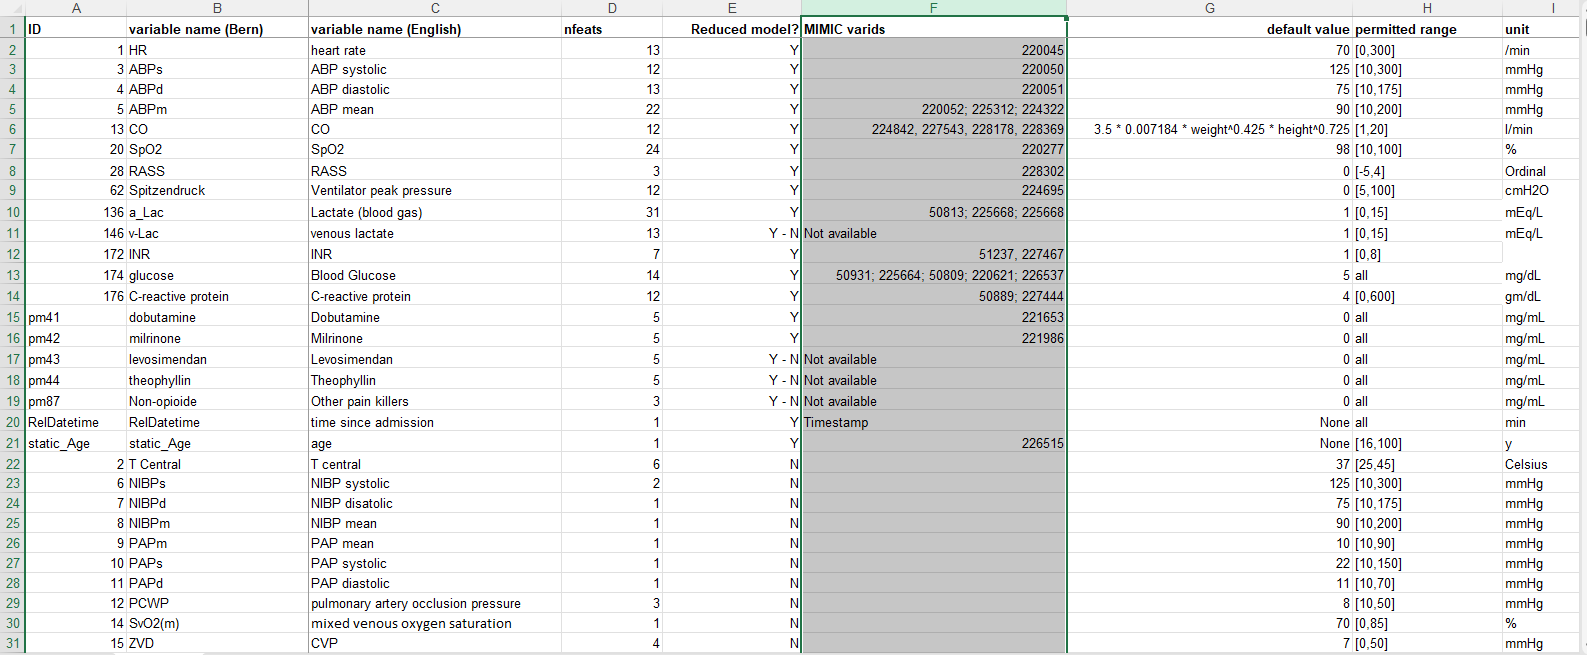

In [17]:
# ------------------------------------------------------------------------------
# Duplicated variable 여부, Variable별 SD 계산
# ------------------------------------------------------------------------------

checks = {
    "chartevents": (chartevents, ["stay_id", "itemid", "charttime"]),
    "labevents": (labevents, ["subject_id", "hadm_id", "itemid", "charttime"]),
    "inputevents": (inputevents, ["stay_id", "itemid", "starttime"]),
    "procedureevents": (procedureevents, ["stay_id", "itemid", "starttime"])
}

results = []

for name, (df, keys) in checks.items():
    dup = df[df.duplicated(keys, keep=False)]

    n_groups = (dup.groupby(keys).ngroups if len(dup) > 0 else 0)

    results.append({
        "table": name,
        "duplicate_rows": len(dup),
        "duplicate_groups": n_groups,
        "duplicate_ratio_%": len(dup) / len(df) * 100
    })

result = pd.DataFrame(results)
display(result)

,table,duplicate_rows,duplicate_groups,duplicate_ratio_%
0,chartevents,4928904,1053447,15.749774
1,labevents,20335,10019,0.579528
2,inputevents,17999,8877,2.213649
3,procedureevents,1316,637,2.936910


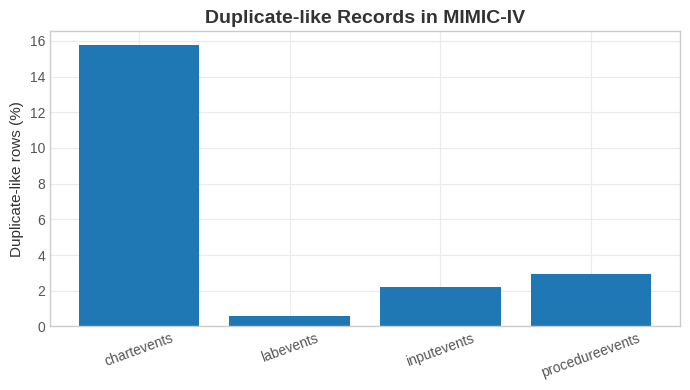

In [18]:
plt.figure(figsize=(7, 4))

plt.bar(
    result["table"],
    result["duplicate_ratio_%"]
)

plt.ylabel("Duplicate-like rows (%)")
plt.title("Duplicate-like Records in MIMIC-IV")

plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

In [19]:
# ------------------------------------------------------------------------------
# Pharma duplicate 처리
# ------------------------------------------------------------------------------

# 3가지 (zero dose처리, tablet 처리, 그외 등) 경우에 해당하는게 얼마나 있는지 확인
dup = inputevents[inputevents.duplicated(
    subset=["stay_id", "itemid", "starttime"], keep=False)].copy()
print("duplicated rows: ", len(dup))

cols = [
    "stay_id", "itemid", "starttime", "endtime",
    "amount", "amountuom", "rate", "rateuom",
    "orderid", "linkorderid",
    "ordercategorydescription",
    "statusdescription"
]

cols = [c for c in cols if c in dup.columns]
display(dup[cols].sort_values(["stay_id", "itemid", "starttime"]).head(50))

duplicated rows:  17999


,stay_id,itemid,starttime,endtime,amount,amountuom,rate,rateuom,orderid,linkorderid,ordercategorydescription,statusdescription
106537,30016014,225974,2110-10-07 21:00:00,2110-10-07 21:01:00,5.000000,mg,NaN,NaN,6300622,6300622,Drug Push,FinishedRunning
106539,30016014,225974,2110-10-07 21:00:00,2110-10-07 21:01:00,5.000000,mg,NaN,NaN,3959570,3959570,Drug Push,FinishedRunning
48220,30030798,220949,2156-01-24 04:00:00,2156-01-24 04:01:00,50.000000,mL,NaN,NaN,7528127,7528127,Drug Push,FinishedRunning
48221,30030798,220949,2156-01-24 04:00:00,2156-01-24 04:01:00,100.000000,mL,NaN,NaN,9190270,9190270,Drug Push,FinishedRunning
48133,30030798,220949,2156-01-24 12:20:00,2156-01-24 12:21:00,50.000000,mL,NaN,NaN,1184247,1184247,Drug Push,FinishedRunning
48134,30030798,220949,2156-01-24 12:20:00,2156-01-24 12:21:00,100.000000,mL,NaN,NaN,4530514,4530514,Drug Push,FinishedRunning
48195,30030798,221668,2156-01-22 23:00:00,2156-01-22 23:01:00,1.000000,mg,NaN,NaN,1666082,1666082,Drug Push,FinishedRunning
48199,30030798,221668,2156-01-22 23:00:00,2156-01-23 10:30:00,57.520279,mg,5.001763,mg/hour,5534711,7144766,Continuous Med,Stopped
48050,30030798,225158,2156-01-24 20:00:00,2156-01-24 20:01:00,1000.000000,mL,NaN,NaN,8883789,8883789,Bolus,FinishedRunning
48051,30030798,225158,2156-01-24 20:00:00,2156-01-24 20:01:00,1000.000000,mL,NaN,NaN,6995251,6995251,Bolus,FinishedRunning


#### 약물 투여 방식
- Bolus: 한 번에 일정량을 빠르게 투여
- Injection: 주사 투여 (injection이라고 무조건 continuous는 아님; 주사기로 10mg 한번 투여는 bolus injection --- Infusion pump로 계속 주입하면 continuous infusion)
- Tablet: 경구제(알약)

#### Acting period
- 어떤 약의 한 번 투여 효과가 지속된다고 가정하는 시간

---

```code
                   Pharmaceutical record
                           │
              ┌────────────┴────────────┐
              │                         │
      Continuous infusion       Bolus / Injection / Tablet
              │                         │
        이미 rate 존재              순간 dose만 존재
              │                         │
              │                  acting period 사용
              │                         │
              └──────────┬──────────────┘
                         ↓
                 정량 rate로 표현 가능?
                    │           │
                   Yes          No
                    │           │
                  RATE       PRESENCE
                              0 / 1
```                              



---
#### HiRID
```code
하나의 Pharma record
     ↓

Status == 780 ?
     ├─ Yes
     │    → instantaneous administration
     │      (injection/tablet/etc.)
     │
     └─ No
          ↓
       InfusionID 안의
       여러 Status + Value + Datetime을 함께 분석
          ↓
       continuous infusion episode 재구성
```

In [20]:
# ------------------------------------------------------------------------------
# 약물 투여 형태 및 최종 표현
# ------------------------------------------------------------------------------
cols = [
    "itemid",
    "starttime",
    "endtime",
    "amount",
    "amountuom",
    "rate",
    "rateuom",
    "ordercategoryname",
    "ordercategorydescription",
    "statusdescription",
]

cols = [c for c in cols if c in inputevents.columns]

display(inputevents[cols].head(30))

print("\n=== ordercategoryname ===")
print(inputevents["ordercategoryname"].value_counts(dropna=False))

print("\n=== ordercategorydescription ===")
print(inputevents["ordercategorydescription"].value_counts(dropna=False))

print("\n=== RATE present / missing ===")
print(inputevents["rate"].notna().value_counts())

,itemid,starttime,endtime,amount,amountuom,rate,rateuom,ordercategoryname,ordercategorydescription,statusdescription
0,221744,2131-01-11 05:50:00,2131-01-11 05:51:00,24.999999,mcg,NaN,NaN,05-Med Bolus,Drug Push,FinishedRunning
1,222168,2131-01-11 06:39:00,2131-01-11 07:47:00,221.354167,mg,50.080132,mcg/kg/min,01-Drips,Continuous Med,ChangeDose/Rate
2,225943,2131-01-11 06:39:00,2131-01-11 07:47:00,22.135415,mL,19.531248,mL/hour,01-Drips,Continuous Med,ChangeDose/Rate
3,225158,2131-01-11 06:49:00,2131-01-12 03:50:00,210.166673,mL,10.000000,mL/hour,02-Fluids (Crystalloids),Continuous IV,Stopped
4,225158,2131-01-11 06:49:00,2131-01-13 08:49:00,500.000015,mL,10.000000,mL/hour,02-Fluids (Crystalloids),Continuous IV,FinishedRunning
5,221744,2131-01-11 06:50:00,2131-01-11 06:51:00,24.999999,mcg,NaN,NaN,05-Med Bolus,Drug Push,FinishedRunning
6,220949,2131-01-11 06:54:00,2131-01-11 07:40:00,13.089431,mL,17.073170,mL/hour,01-Drips,Continuous Med,ChangeDose/Rate
7,221662,2131-01-11 06:54:00,2131-01-11 07:40:00,20.943088,mg,7.004377,mcg/kg/min,01-Drips,Continuous Med,ChangeDose/Rate
8,225797,2131-01-15 20:00:00,2131-01-15 20:01:00,30.000000,mL,NaN,NaN,14-Oral/Gastric Intake,Bolus,FinishedRunning
9,225799,2131-01-15 20:00:00,2131-01-15 20:01:00,50.000000,mL,NaN,NaN,14-Oral/Gastric Intake,Bolus,FinishedRunning



=== ordercategoryname ===
ordercategoryname
01-Drips                    350396
08-Antibiotics (IV)         104474
14-Oral/Gastric Intake       93194
02-Fluids (Crystalloids)     85264
05-Med Bolus                 76397
13-Enteral Nutrition         23302
06-Insulin (Non IV)          20308
10-Prophylaxis (IV)          17160
11-Prophylaxis (Non IV)      14765
03-IV Fluid Bolus             9709
07-Blood Products             7084
04-Fluids (Colloids)          3617
12-Parenteral Nutrition       2631
16-Pre Admission/Non-ICU      2303
09-Antibiotics (Non IV)       2062
15-Supplements                 426
Name: count, dtype: int64

=== ordercategorydescription ===
ordercategorydescription
Continuous Med    350396
Drug Push         233104
Continuous IV     121898
Bolus             105632
Non Iv Meds         2062
Name: count, dtype: int64

=== RATE present / missing ===
rate
True     441094
False    371998
Name: count, dtype: int64


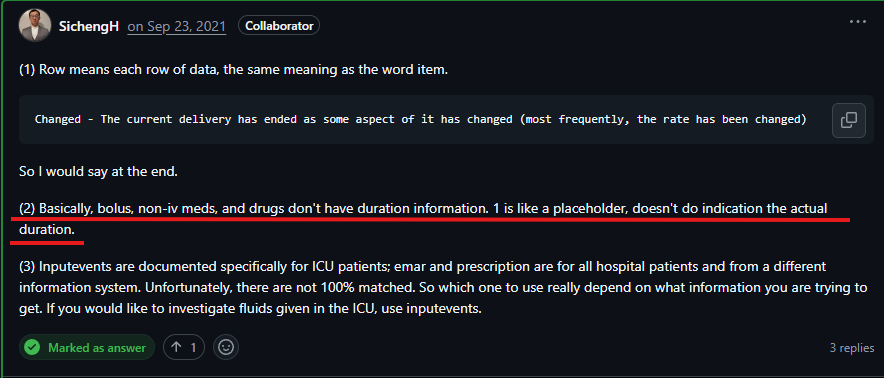

In [22]:
# ------------------------------------------------------------------------------
# 불연속인 약물에 대한 처리 -> 불연속/추가확인 그룹의 실제 약물들을 논문 Table 4와 매핑해서, acting period를 적용할 수 있는지 확인
# Bolus / injection / tablet
# (식별된 순간투여 변환 방법)
# &
# 약물별 Acting period
# (변환에 필요한 약물별 param)
#
# 연속 투여: Continuous Med, Continuous IV
# 불연속 투여: Drug Push, Bolus
# Table 4를 보면서 따로 매칭 확인: Non Iv Meds
#    - 이게 논문에서 사용하는 약물 변수인지
#    - Table 4의 어떤 drug 또는 drug class에 대응하는지
#    - 그 Table 4 항목이 acting period 기반 rate인지, 아니면 presence indicator로 처리되는 항목인지
# ------------------------------------------------------------------------------

# Continuous는 제외하고
check = (
    inputevents[
        inputevents["ordercategorydescription"].isin(
            ["Drug Push", "Bolus", "Non Iv Meds"]
        )
    ]
    .merge(
        d_items[["itemid", "label"]],  # inputevents의 itemid가 있는데 d_items를 붙여주기
        on="itemid",
        how="left"
    )
    .groupby(["itemid", "label", "ordercategorydescription"])
    .size()
    .reset_index(name="count")
    # .sort_values("count", ascending=False)
)

display(check)

,itemid,label,ordercategorydescription,count
0,220949,Dextrose 5%,Bolus,85
1,220949,Dextrose 5%,Drug Push,38351
2,220950,Dextrose 10%,Bolus,1
3,220952,Dextrose 50%,Drug Push,1168
4,221282,Adenosine,Drug Push,53
...,...,...,...,...
157,229615,Esomeprazole (Nexium),Drug Push,13
158,229616,Ondansetron (Zofran),Drug Push,185
159,229617,Epinephrine.,Drug Push,6
160,229618,Calcium Chloride,Drug Push,45


In [24]:
# 위에서 만든 불연속+확인필요를 모아둔 check table을 이용해서...
# 몇 종류의 itemid/약물이 매칭되는가
# 실제 event 개수 기준으로 얼마나 커버되는가

import re

# Table 4 drugs sheet
table4 = pd.read_excel(
    "/content/drive/MyDrive/DAHS/datasets/Supplementary_TABLE4.xlsx",
    sheet_name="drugs"
)

def norm(x):
    if pd.isna(x):
        return ""
    x = str(x).lower()

    # 괄호 안 상품명 제거: Ondansetron (Zofran) -> ondansetron
    x = re.sub(r"\([^)]*\)", "", x)

    # 특수문자/공백 제거
    x = re.sub(r"[^a-z0-9]", "", x)

    return x


# MIMIC-IV
check["key"] = check["label"].apply(norm)

# Table 4
table4["const_key"] = table4["constituent drugs (if relevant)"].apply(norm)
table4["drug_key"] = table4["drug"].apply(norm)


# constituent 또는 drug 이름과 직접 매칭
def find_match(key):
    m = table4[
        (table4["const_key"] == key) |
        (table4["drug_key"] == key)
    ]

    if len(m) == 0:
        return pd.Series([None, None, None])

    r = m.iloc[0]

    return pd.Series([
        r["drug"],
        r["constituent drugs (if relevant)"],
        r["acting period (individual)"]
    ])


check[
    ["table4_drug", "table4_constituent", "acting_period"]
] = check["key"].apply(find_match)


print("전체:", len(check))
print("자동 매칭:", check["acting_period"].notna().sum())
print("미매칭:", check["acting_period"].isna().sum())

display(
    check[
        ["itemid", "label", "ordercategorydescription",
         "count", "table4_drug",
         "table4_constituent", "acting_period"]
    ]
)

전체: 162
자동 매칭: 23
미매칭: 139


,itemid,label,ordercategorydescription,count,table4_drug,table4_constituent,acting_period
0,220949,Dextrose 5%,Bolus,85,None,None,None
1,220949,Dextrose 5%,Drug Push,38351,None,None,None
2,220950,Dextrose 10%,Bolus,1,None,None,None
3,220952,Dextrose 50%,Drug Push,1168,None,None,None
4,221282,Adenosine,Drug Push,53,None,None,None
...,...,...,...,...,...,...,...
157,229615,Esomeprazole (Nexium),Drug Push,13,None,None,None
158,229616,Ondansetron (Zofran),Drug Push,185,None,None,None
159,229617,Epinephrine.,Drug Push,6,None,None,None
160,229618,Calcium Chloride,Drug Push,45,None,None,None


In [31]:
# 23개 matched만 추출
matched_23 = check[
    check["acting_period"].notna()
].copy()

# 필요한 컬럼만 정리
matched_23 = matched_23[
    [
        "itemid",
        "label",
        "ordercategorydescription",
        "count",
        "table4_drug",
        "table4_constituent",
        "acting_period"
    ]
].sort_values("count", ascending=False)

display(matched_23)

,itemid,label,ordercategorydescription,count,table4_drug,table4_constituent,acting_period
13,221744,Fentanyl,Drug Push,20887,NaN,Fentanyl,1h
36,225798,Vancomycin,Drug Push,10652,NaN,vancomycin,24h
20,222168,Propofol,Drug Push,9889,propofol,propofol,5m
87,225893,Piperacillin/Tazobactam (Zosyn),Drug Push,6333,NaN,Piperacillin/Tazobactam,24h
79,225883,Meropenem,Drug Push,5238,NaN,Meropenem,24h
113,225974,Metoprolol,Drug Push,4410,NaN,Metoprolol,24h
58,225859,Ciprofloxacin,Drug Push,1408,NaN,Ciprofloxacin,24h
54,225850,Cefazolin,Drug Push,1353,NaN,Cefazolin,24h
29,225153,Labetalol,Drug Push,1256,NaN,labetalol,4h
37,225798,Vancomycin,Non Iv Meds,1141,NaN,vancomycin,24h


In [32]:
matched_23.to_csv(
    "/content/drive/MyDrive/DAHS/datasets/"
    "mimic4_noncontinuous_drug_acting_period_mapping.csv",
    index=False
)

```code
같은 physiology/lab concept
→ 하나의 변수로 merge
→ 같은 시점에 여러 값이면 median

같은 pharmaceutical compound
→ 하나의 compound 변수로 merge
→ 동시에 여러 infusion이면 논문의 약물 merge 규칙 적용

여러 constituent drug → 하나의 drug class
→ Table 4의 정의에 따라 presence / count 등으로 표현
```

In [36]:
# ------------------------------------------------------------------------------
# 동일 physiological concept
# ------------------------------------------------------------------------------

# MAP 관련 item 검색
d_items[
    d_items["label"].str.contains(
        "blood pressure mean|mean blood pressure|mean arterial pressure",
        case=False,
        na=False
    )
][["itemid", "label", "category", "unitname"]]

,itemid,label,category,unitname
8,220052,Arterial Blood Pressure mean,Routine Vital Signs,mmHg
26,220181,Non Invasive Blood Pressure mean,Routine Vital Signs,mmHg


In [37]:
# ------------------------------------------------------------------------------
# 동일 pharmaceutical compound
# ------------------------------------------------------------------------------

# inputevents에서 실제 사용된 itemid만
used_drug_items = (
    d_items[d_items["itemid"].isin(inputevents["itemid"].unique())]
    [["itemid", "label", "category", "unitname"]]
    .copy()
)

# 우선 대표적인 약물 몇 개 검색
keywords = [
    "norepinephrine",
    "epinephrine",
    "vasopressin",
    "vancomycin",
    "heparin",
    "insulin"
]

for drug in keywords:
    print(f"\n=== {drug} ===")
    display(
        used_drug_items[
            used_drug_items["label"].str.contains(
                drug,
                case=False,
                na=False
            )
        ].sort_values("label")
    )


=== norepinephrine ===


,itemid,label,category,unitname
305,221906,Norepinephrine,Medications,mg



=== epinephrine ===


,itemid,label,category,unitname
280,221289,Epinephrine,Medications,mg
3737,229617,Epinephrine.,Medications,mg
305,221906,Norepinephrine,Medications,mg



=== vasopressin ===


...

,itemid,label,category,unitname
1539,225798,Vancomycin,Antibiotics,dose



=== heparin ===


,itemid,label,category,unitname
1108,225152,Heparin Sodium,Medications,units
3722,229597,Heparin Sodium (Impella),Medications,units
1671,225975,Heparin Sodium (Prophylaxis),Medications,dose



=== insulin ===


,itemid,label,category,unitname
323,223257,Insulin - 70/30,Medications,units
326,223260,Insulin - Glargine,Medications,units
328,223262,Insulin - Humalog,Medications,units
327,223261,Insulin - Humalog 75/25,Medications,units
325,223259,Insulin - NPH,Medications,units
3517,229299,Insulin - Novolog,Medications,units
324,223258,Insulin - Regular,Medications,units


In [40]:
# ------------------------------------------------------------------------------
# Rare drug -> 상위 class
# "for example, foscavir was observed < 50 times..."
# ------------------------------------------------------------------------------

# 1. MIMIC-IV inputevents에서 item별 사용 빈도 계산
drug_freq = (
    inputevents
    .merge(
        d_items[["itemid", "label"]],
        on="itemid",
        how="left"
    )
    .groupby(["itemid", "label"])
    .size()
    .reset_index(name="count")
)

# 2. count < 50인 rare item만 추출
rare_drugs = drug_freq[
    drug_freq["count"] < 50
].copy()

print("Rare items:", len(rare_drugs))

display(
    rare_drugs.sort_values("count")
)

Rare items: 76


,itemid,label,count
9,221261,Abciximab (Reopro),1
41,222151,Procainamide,1
135,225915,Profilnine,1
103,225868,Ethambutol,1
109,225877,Isoniazid,1
...,...,...,...
146,225937,Ensure (Full),42
178,226375,PACU Crystalloid Intake,43
213,228140,Dextrose 20%,44
86,225840,Amikacin,46


In [41]:
# 위 76개 약물을 Table 4와 매칭

# 이름 정규화
rare_drugs["key"] = rare_drugs["label"].apply(norm)

table4["const_key"] = (
    table4["constituent drugs (if relevant)"].apply(norm)
)

# rare drug ↔ constituent drug direct match
rare_matched = rare_drugs.merge(
    table4[
        [
            "drug",
            "constituent drugs (if relevant)",
            "merging ratio",
            "const_key"
        ]
    ],
    left_on="key",
    right_on="const_key",
    how="left"
)

display(
    rare_matched[
        [
            "itemid",
            "label",
            "count",
            "drug",
            "constituent drugs (if relevant)",
            "merging ratio"
        ]
    ].sort_values("count")
)

,itemid,label,count,drug,constituent drugs (if relevant),merging ratio
1,221261,Abciximab (Reopro),1,NaN,Abciximab,binary
7,222151,Procainamide,1,NaN,NaN,NaN
30,225915,Profilnine,1,NaN,NaN,NaN
21,225868,Ethambutol,1,NaN,Ethambutol,binary
24,225877,Isoniazid,1,NaN,Isoniazid,binary
...,...,...,...,...,...,...
32,225937,Ensure (Full),42,NaN,NaN,NaN
44,226375,PACU Crystalloid Intake,43,NaN,NaN,NaN
57,228140,Dextrose 20%,44,NaN,NaN,NaN
18,225840,Amikacin,46,NaN,NaN,NaN


In [42]:
matched_rare = rare_matched[
    rare_matched["constituent drugs (if relevant)"].notna()
]

print("Rare items 전체:", rare_drugs["itemid"].nunique())
print("Table 4 매칭:", matched_rare["itemid"].nunique())
print(
    "매칭률:",
    f"{matched_rare['itemid'].nunique() / rare_drugs['itemid'].nunique() * 100:.2f}%"
)

Rare items 전체: 76
Table 4 매칭: 6
매칭률: 7.89%


In [43]:
# ------------------------------------------------------------------------------
# Merge 이후 동일 timestamp 중복 처리
# ------------------------------------------------------------------------------


# 1. physiology/lab → median
# 두 itemid가 같은 stay, 같은 charttime에 동시에 존재하는 경우
map_events = chartevents[
    chartevents["itemid"].isin([220052, 220181])
].copy()

# 같은 stay + 같은 시각에 MAP measurement가 2개 이상 있는 경우
map_same_time = (
    map_events
    .groupby(["stay_id", "charttime"])
    .agg(
        n_records=("valuenum", "size"),
        n_itemids=("itemid", "nunique")
    )
    .reset_index()
)

collision = map_same_time[
    map_same_time["n_itemids"] > 1
]

print("MAP 동시 측정 시점 수:", len(collision))
print(
    "전체 MAP 시점 중 비율:",
    f"{len(collision) / len(map_same_time) * 100:.3f}%"
)

display(collision.head(20))

MAP 동시 측정 시점 수: 12655
전체 MAP 시점 중 비율: 2.249%


,stay_id,charttime,n_records,n_itemids
249,30015055,2188-05-11 06:00:00,2,2
250,30015055,2188-05-11 07:00:00,2,2
253,30015055,2188-05-11 09:00:00,2,2
254,30015055,2188-05-11 10:00:00,2,2
275,30016014,2110-10-07 01:00:00,2,2
276,30016014,2110-10-07 02:00:00,2,2
277,30016014,2110-10-07 03:00:00,2,2
278,30016014,2110-10-07 04:00:00,2,2
279,30016014,2110-10-07 05:00:00,2,2
280,30016014,2110-10-07 06:00:00,2,2


In [46]:
# 2. pharmaceutical infusion → weighted sum
heparin_ids = [225152, 229597, 225975]

hep = inputevents[
    inputevents["itemid"].isin(heparin_ids)
].copy()

# 시간 구간이 겹치는 infusion episode 확인
hep = hep[
    hep["rate"].notna()
].sort_values(["stay_id", "starttime"])

display(
    hep[
        ["stay_id", "itemid", "starttime", "endtime",
         "rate", "rateuom", "amount", "amountuom"]
    ].head(50)
)

서로 다른 Heparin itemid 간 겹치는 infusion pair: 260


,stay_id,itemid_a,starttime_a,endtime_a,rate_a,itemid_b,starttime_b,endtime_b,rate_b
18833,39879701,229597,2139-11-27 07:41:00,2139-11-29 03:54:00,348.884247,225152,2139-11-28 14:22:00,2139-11-29 03:53:00,699.807007
18888,39879701,229597,2139-11-27 07:41:00,2139-11-29 03:54:00,348.884247,225152,2139-11-29 03:53:00,2139-11-29 13:09:00,934.994629
18936,39879701,229597,2139-11-27 07:41:00,2139-11-29 03:54:00,348.884247,225152,2139-11-28 00:37:00,2139-11-28 14:22:00,500.120605
18980,39879701,229597,2139-11-27 07:41:00,2139-11-29 03:54:00,348.884247,225152,2139-11-26 21:00:00,2139-11-28 00:37:00,500.060303
19940,39879701,229597,2139-11-25 13:02:00,2139-11-25 17:59:00,349.941010,225152,2139-11-25 14:00:00,2139-11-25 22:08:00,249.999985
20101,39879701,229597,2139-11-25 17:59:00,2139-11-25 21:55:00,400.057678,225152,2139-11-25 14:00:00,2139-11-25 22:08:00,249.999985
20433,39879701,225152,2139-11-28 14:22:00,2139-11-29 03:53:00,699.807007,229597,2139-11-27 07:41:00,2139-11-29 03:54:00,348.884247
20660,39879701,225152,2139-11-29 13:09:00,2139-11-30 15:42:00,920.150757,229597,2139-11-29 03:54:00,2139-11-30 02:59:00,274.291779
20661,39879701,225152,2139-11-29 13:09:00,2139-11-30 15:42:00,920.150757,229597,2139-11-30 02:59:00,2139-12-01 05:42:00,274.123291
20828,39879701,229597,2139-11-14 08:19:00,2139-11-14 09:15:00,925.198486,225152,2139-11-13 23:29:00,2139-11-14 20:00:00,499.999969


In [49]:
# 3. drug class → presence / count

# Table 4에서 실제 상위 변수/클래스 이름
table4["drug_group"] = table4["temp: bern name"].ffill()

# matched_23과 Table 4 연결
tmp = matched_23.merge(
    table4[
        [
            "drug_group",
            "constituent drugs (if relevant)",
            "merging ratio"
        ]
    ],
    left_on="table4_constituent",
    right_on="constituent drugs (if relevant)",
    how="left"
)

# MIMIC-IV에서 같은 class에 몇 종류의 약물이 매칭되는지 확인
class_summary = (
    tmp.groupby("drug_group")
    .agg(
        n_itemids=("itemid", "nunique"),
        n_constituents=("table4_constituent", "nunique")
    )
    .sort_values("n_constituents", ascending=False)
)

display(class_summary)

,n_itemids,n_constituents
drug_group,,
Administriation of antibiotics,12,12
B-Blocker,2,2
Ca Antagonists,2,2
Opiate,1,1
Propofol,1,1


In [50]:
# ------------------------------------------------------------------------------
# 1. MIMIC-IV에서 사용할 약물 변수 선정
#    - continuous 약물
#    - acting period로 살릴 수 있는 non-continuous 약물 (23개, 18종)

# 2. 이 약물들을 최종 pharmaceutical variable로 mapping

# 3. 실제로 여러 itemid가 하나의 변수로 합쳐지는 경우만 찾기

# 4. 그 merging 대상들에 대해 Table 4의 merging ratio 확인

# 5. 대부분 ratio가 있으면 그대로 적용
#    일부 1~5종 정도만 ratio가 없으면
#    → 그 소수 케이스만 별도 처리/제외/보수적 대응
# ------------------------------------------------------------------------------

def norm(x):
    if pd.isna(x):
        return ""
    x = str(x).lower()
    x = re.sub(r"\([^)]*\)", "", x)
    return re.sub(r"[^a-z0-9]", "", x)

# MIMIC-IV에서 실제 사용된 약물
drugs = (
    inputevents[["itemid"]]
    .drop_duplicates()
    .merge(d_items[["itemid", "label"]], on="itemid", how="left")
)

drugs["key"] = drugs["label"].apply(norm)

# Table 4
t4 = table4.copy()
t4["drug_key"] = t4["drug"].apply(norm)
t4["const_key"] = t4["constituent drugs (if relevant)"].apply(norm)

# constituent 기준 매칭
result = drugs.merge(
    t4[
        ["drug", "constituent drugs (if relevant)", "merging ratio", "const_key"]
    ],
    left_on="key",
    right_on="const_key",
    how="left"
)

print("전체 MIMIC-IV itemid:", len(drugs))
print("Table4 매칭:", result["constituent drugs (if relevant)"].notna().sum())
print("merging ratio 있음:", result["merging ratio"].notna().sum())

display(
    result[result["merging ratio"].notna()][
        ["itemid", "label", "drug",
         "constituent drugs (if relevant)", "merging ratio"]
    ]
)

전체 MIMIC-IV itemid: 269
Table4 매칭: 23
merging ratio 있음: 23


,itemid,label,drug,constituent drugs (if relevant),merging ratio
0,221744,Fentanyl,NaN,Fentanyl,100
1,222168,Propofol,propofol,propofol,1
11,225798,Vancomycin,NaN,vancomycin,binary
19,225942,Fentanyl (Concentrate),NaN,Fentanyl,100
26,221906,Norepinephrine,norepinephrine,norepinephrine,1
28,225859,Ciprofloxacin,NaN,Ciprofloxacin,binary
29,225883,Meropenem,NaN,Meropenem,binary
32,225893,Piperacillin/Tazobactam (Zosyn),NaN,Piperacillin/Tazobactam,binary
63,221468,Diltiazem,NaN,Diltiazem,0.083333
71,225974,Metoprolol,NaN,Metoprolol,0.5


In [58]:
def norm(x):
    if pd.isna(x):
        return ""
    x = str(x).lower()
    x = re.sub(r"\([^)]*\)", "", x)
    return re.sub(r"[^a-z0-9]", "", x)

# 1) 사용할 약물 pool
noncont = pd.read_csv(
    "/content/drive/MyDrive/DAHS/datasets/mimic4_noncontinuous_drug_acting_period_mapping.csv"
)

noncont_ids = set(noncont["itemid"])

cont_ids = set(
    inputevents.loc[
        inputevents["ordercategorydescription"].isin(
            ["Continuous Med", "Continuous IV"]
        ),
        "itemid"
    ]
)

drug_ids = cont_ids | noncont_ids

drugs = (
    pd.DataFrame({"itemid": list(drug_ids)})
    .merge(d_items[["itemid", "label"]], on="itemid", how="left")
)

drugs["key"] = drugs["label"].apply(norm)


# 2) 같은 약물 이름으로 묶이는 itemid 찾기
merge_groups = (
    drugs.groupby("key")
    .agg(
        n_itemids=("itemid", "nunique"),
        labels=("label", lambda x: ", ".join(sorted(set(x))))
    )
    .query("n_itemids >= 2")
    .reset_index()
)

print("실제 merge 그룹:", len(merge_groups))
display(merge_groups)


# 3) Table 4 numeric merging ratio 준비
t4 = table4.copy()
t4["key"] = t4["constituent drugs (if relevant)"].apply(norm)
t4["ratio_num"] = pd.to_numeric(t4["merging ratio"], errors="coerce")

ratio_keys = set(
    t4.loc[t4["ratio_num"].notna(), "key"]
)


# 4) merge 그룹 중 ratio 사용 가능한 그룹
merge_groups["ratio_available"] = merge_groups["key"].isin(ratio_keys)

print(
    "Table4 ratio 사용 가능한 merge 그룹:",
    merge_groups["ratio_available"].sum()
)

display(merge_groups)

실제 merge 그룹: 17


,key,n_itemids,labels
0,acdacitrate,2,"ACD-A Citrate (1000ml), ACD-A Citrate (500ml)"
1,bivalirudin,2,"Bivalirudin (Angiomax), Bivalirudin (Angiomax)..."
2,calciumgluconate,3,"Calcium Gluconate, Calcium Gluconate (Bolus), ..."
3,dexmedetomidine,2,Dexmedetomidine (Precedex)
4,fentanyl,2,"Fentanyl, Fentanyl (Concentrate)"
5,heparinsodium,2,"Heparin Sodium, Heparin Sodium (Impella)"
6,impactwithfiber,2,"Impact with Fiber (1/2), Impact with Fiber (Full)"
7,kcl,2,"KCL (Bolus), KCl (CRRT)"
8,magnesiumsulfate,3,"Magnesium Sulfate, Magnesium Sulfate (Bolus), ..."
9,nepro,2,"Nepro (1/2), Nepro (Full)"


Table4 ratio 사용 가능한 merge 그룹: 1


,key,n_itemids,labels,ratio_available
0,acdacitrate,2,"ACD-A Citrate (1000ml), ACD-A Citrate (500ml)",False
1,bivalirudin,2,"Bivalirudin (Angiomax), Bivalirudin (Angiomax)...",False
2,calciumgluconate,3,"Calcium Gluconate, Calcium Gluconate (Bolus), ...",False
3,dexmedetomidine,2,Dexmedetomidine (Precedex),False
4,fentanyl,2,"Fentanyl, Fentanyl (Concentrate)",True
5,heparinsodium,2,"Heparin Sodium, Heparin Sodium (Impella)",False
6,impactwithfiber,2,"Impact with Fiber (1/2), Impact with Fiber (Full)",False
7,kcl,2,"KCL (Bolus), KCl (CRRT)",False
8,magnesiumsulfate,3,"Magnesium Sulfate, Magnesium Sulfate (Bolus), ...",False
9,nepro,2,"Nepro (1/2), Nepro (Full)",False


In [60]:
# ------------------------------------------------------------------------------
# 각 ICU stay마다 5분 grid 생성 가능 여부
# HiRID: 첫 HR measurement부터 마지막 HR measurement까지 5-min grid 생성, 최대 28일
# ------------------------------------------------------------------------------

icustays["intime"] = pd.to_datetime(icustays["intime"])
icustays["outtime"] = pd.to_datetime(icustays["outtime"])
chartevents["charttime"] = pd.to_datetime(chartevents["charttime"])

hr = chartevents[
    (chartevents["itemid"] == 220045) &
    (chartevents["valuenum"].notna())
].copy()

hr_range = (
    hr.groupby("stay_id")["charttime"]
    .agg(first_hr="min", last_hr="max")
    .reset_index()
)

check_grid = icustays[
    ["stay_id", "intime", "outtime"]
].merge(
    hr_range,
    on="stay_id",
    how="left"
)

check_grid["grid_end"] = check_grid[
    ["last_hr"]
].min(axis=1)

check_grid["max_28d"] = (
    check_grid["intime"] + pd.Timedelta(days=28)
)

check_grid["grid_end"] = check_grid[
    ["last_hr", "max_28d"]
].min(axis=1)

print("전체 stay:", len(check_grid))
print("HR 없는 stay:", check_grid["first_hr"].isna().sum())
print(
    "first HR > grid end:",
    (check_grid["first_hr"] > check_grid["grid_end"]).sum()
)

display(check_grid.head())

전체 stay: 3000
HR 없는 stay: 0
first HR > grid end: 0


,stay_id,intime,outtime,first_hr,last_hr,grid_end,max_28d
0,37510196,2131-01-11 04:20:05,2131-01-20 08:27:30,2131-01-11 04:22:00,2131-01-20 04:00:00,2131-01-20 04:00:00,2131-02-08 04:20:05
1,35479615,2156-05-11 14:49:34,2156-05-22 14:16:46,2156-05-11 16:03:00,2156-05-22 13:00:00,2156-05-22 13:00:00,2156-06-08 14:49:34
2,38875437,2156-04-19 18:11:19,2156-04-26 18:58:41,2156-04-19 18:17:00,2156-04-26 18:00:00,2156-04-26 18:00:00,2156-05-17 18:11:19
3,39635619,2174-12-04 11:28:24,2174-12-12 20:03:01,2174-12-04 12:17:00,2174-12-12 17:00:00,2174-12-12 17:00:00,2175-01-01 11:28:24
4,31361200,2151-06-06 14:06:06,2151-06-13 22:03:23,2151-06-06 17:23:00,2151-06-13 21:00:00,2151-06-13 21:00:00,2151-07-04 14:06:06


In [64]:
# ------------------------------------------------------------------------------
# 각 variable별 Sampling interval & Variable별 imputation horizon
# ------------------------------------------------------------------------------

def interval_stats(df, time_col):
    x = df.sort_values(["stay_id", time_col]).copy()

    x["interval_min"] = (
        x.groupby("stay_id")[time_col]
        .diff()
        .dt.total_seconds() / 60
    )

    x = x.loc[x["interval_min"] > 0, "interval_min"].dropna()

    return {
        "median": x.median(),
        "Q1": x.quantile(0.25),
        "Q3": x.quantile(0.75),
        "IQR": x.quantile(0.75) - x.quantile(0.25)
    }


# HR
hr = chartevents[
    (chartevents["itemid"] == 220045) &
    chartevents["valuenum"].notna()
][["stay_id", "charttime"]].copy()

# MAP
map_df = chartevents[
    chartevents["itemid"].isin([220052, 220181]) &
    chartevents["valuenum"].notna()
][["stay_id", "charttime"]].drop_duplicates()

# Lactate
lac = labevents[
    (labevents["itemid"] == 50813) &
    labevents["valuenum"].notna()
][["hadm_id", "charttime"]].copy()

# ICU stay 연결
lac = lac.merge(
    icustays[["stay_id", "hadm_id", "intime", "outtime"]],
    on="hadm_id",
    how="inner"
)

# 실제 ICU 입실 중 측정된 lactate만
lac = lac[
    (lac["charttime"] >= lac["intime"]) &
    (lac["charttime"] <= lac["outtime"])
][["stay_id", "charttime"]]

lac["charttime"] = pd.to_datetime(lac["charttime"])

print("HR      :", interval_stats(hr, "charttime"))
print("MAP     :", interval_stats(map_df, "charttime"))
print("Lactate :", interval_stats(lac, "charttime"))

HR      : {'median': 60.0, 'Q1': np.float64(60.0), 'Q3': np.float64(60.0), 'IQR': np.float64(0.0)}
MAP     : {'median': 60.0, 'Q1': np.float64(60.0), 'Q3': np.float64(60.0), 'IQR': np.float64(0.0)}
Lactate : {'median': 357.0, 'Q1': np.float64(201.0), 'Q3': np.float64(738.0), 'IQR': np.float64(537.0)}


In [68]:
# ------------------------------------------------------------------------------
# default / normal value
# ------------------------------------------------------------------------------
table4_var = pd.read_excel(
    "/content/drive/MyDrive/DAHS/datasets/Supplementary_TABLE4.xlsx",
    sheet_name="master list"
)

display(
    table4_var[
        table4_var["variable name (English)"].str.contains(
            "heart|pressure|lactate|oxygen",
            case=False,
            na=False
        )
    ][
        ["variable name (English)", "default value", "unit", "type"]
    ]
)

,variable name (English),default value,unit,type
0,heart rate,70,/min,physiol
7,Ventilator peak pressure,0,cmH2O,physiol
8,Lactate (blood gas),1,mEq/L,lab
9,venous lactate,1,mEq/L,lab
27,pulmonary artery occlusion pressure,8,mmHg,physiol
28,mixed venous oxygen saturation,70,%,physiol
35,Supplemental oxygen,0,l/min,treatment
48,Ventilator plateau pressure,0,cmH2O,physiol
49,Ventilator mean airway pressure,0,cmH2O,physiol
64,Central venous oxygen saturation,65,%,lab


In [69]:
# ------------------------------------------------------------------------------
# Static variable 존재 여부
# ------------------------------------------------------------------------------

# 1. Age / Sex
print("=== Age ===")
print("missing:", patients["anchor_age"].isna().sum())

print("\n=== Sex ===")
print(patients["gender"].value_counts(dropna=False))


# 2. Admission type
print("\n=== Admission type ===")
print(admissions["admission_type"].value_counts(dropna=False))


# 3. Height
height = chartevents[
    (chartevents["itemid"] == 226730) &
    chartevents["valuenum"].notna()
]

print("\n=== Height ===")
print("measurements:", len(height))
print("stays:", height["stay_id"].nunique())


# 4. APACHE diagnostic-related items
apache_ids = [226740, 226741, 226742]

apache = chartevents[
    chartevents["itemid"].isin(apache_ids)
]

print("\n=== APACHE diagnostic ===")
print("measurements:", len(apache))
print("stays:", apache["stay_id"].nunique())
print(apache["itemid"].value_counts())

=== Age ===
missing: 0

=== Sex ===
gender
M    1623
F    1167
Name: count, dtype: int64

=== Admission type ===
admission_type
EW EMER.                       1461
URGENT                          713
OBSERVATION ADMIT               433
DIRECT EMER.                    136
SURGICAL SAME DAY ADMISSION      98
ELECTIVE                         40
Name: count, dtype: int64

=== Height ===
measurements: 1957
stays: 1957

=== APACHE diagnostic ===
measurements: 0
stays: 0
Series([], Name: count, dtype: int64)


In [70]:
# ------------------------------------------------------------------------------
# Lactate, MAP, Vasoactive/Intropic
#  45-min centered window, 30-min rule
# ------------------------------------------------------------------------------
# ---------- 1. Lactate ----------
# 우리가 앞에서 확인한 대표 MIMIC-IV lactate ITEMID
LAC_IDS = [50813]

lac = labevents[
    labevents["itemid"].isin(LAC_IDS) &
    labevents["valuenum"].notna()
][["hadm_id", "itemid", "charttime", "valuenum"]].copy()

lac["charttime"] = pd.to_datetime(lac["charttime"])

lac = lac.merge(
    icustays[["stay_id", "hadm_id", "intime", "outtime"]],
    on="hadm_id",
    how="inner"
)

lac = lac[
    (lac["charttime"] >= pd.to_datetime(lac["intime"])) &
    (lac["charttime"] <= pd.to_datetime(lac["outtime"]))
]

print("=== Lactate ===")
print("measurements:", len(lac))
print("stays:", lac["stay_id"].nunique())
print("range:", lac["valuenum"].min(), "~", lac["valuenum"].max())
print("> 2 mmol/L:", (lac["valuenum"] > 2).sum())


# ---------- 2. MAP ----------
# arterial MAP + non-invasive MAP
MAP_IDS = [220052, 220181]

map_df = chartevents[
    chartevents["itemid"].isin(MAP_IDS) &
    chartevents["valuenum"].notna()
][["stay_id", "itemid", "charttime", "valuenum"]].copy()

print("\n=== MAP ===")
print("measurements:", len(map_df))
print("stays:", map_df["stay_id"].nunique())
print("range:", map_df["valuenum"].min(), "~", map_df["valuenum"].max())
print("<= 65 mmHg:", (map_df["valuenum"] <= 65).sum())


# ---------- 3. Vasoactive / Inotropic drugs ----------
VASO_IDS = {
    221906: "Norepinephrine",
    221289: "Epinephrine",
    221662: "Dopamine",
    221653: "Dobutamine",
    222315: "Vasopressin",
    221749: "Phenylephrine",
    221986: "Milrinone",
}

vaso = inputevents[
    inputevents["itemid"].isin(VASO_IDS)
].copy()

vaso["drug"] = vaso["itemid"].map(VASO_IDS)

print("\n=== Vasoactive / Inotropic ===")
print("events:", len(vaso))
print("stays:", vaso["stay_id"].nunique())
print(vaso["drug"].value_counts())


=== Lactate ===
measurements: 23204
stays: 2986
range: 0.3 ~ 26.0
> 2 mmol/L: 8380

=== MAP ===
measurements: 575294
stays: 2993
range: -22767.0 ~ 1234570.0
<= 65 mmHg: 102797

=== Vasoactive / Inotropic ===
events: 51691
stays: 1377
drug
Norepinephrine    34954
Phenylephrine     11447
Vasopressin        2301
Epinephrine        1013
Dopamine            884
Dobutamine          757
Milrinone           335
Name: count, dtype: int64
